In [14]:
import sys
import numpy as np
import pandas as pd

from one.api import ONE
from brainbox.io.one import SessionLoader

from brainwidemap.bwm_loading import load_good_units, load_trials_and_mask, merge_probes

from brainwidemap.decoding.functions.decoding import fit_eid
from brainwidemap.decoding.functions.process_targets import load_behavior
from brainwidemap.decoding.settings_template import params
from brainwidemap.bwm_loading import bwm_query, load_good_units, load_trials_and_mask
from brainbox.io.one import SessionLoader
from brainwidemap.bwm_loading import load_trials_and_mask
from prior_localization.functions.utils import compute_mask
import tempfile
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from one.api import ONE
from prior_localization.fit_data import fit_session_ephys, fit_session_widefield
from brainwidemap.decoding.functions.process_inputs import select_ephys_regions
from brainwidemap.decoding.functions.process_inputs import preprocess_ephys
from brainwidemap.decoding.functions.process_targets import compute_beh_target
from brainwidemap.decoding.functions.process_targets import compute_target_mask
from brainwidemap.decoding.functions.process_targets import transform_data_for_decoding
from brainwidemap.decoding.functions.process_targets import logisticreg_criteria
from brainwidemap.decoding.functions.process_targets import get_target_data_per_trial_wrapper

In [3]:
one = ONE(
    base_url="https://openalyx.internationalbrainlab.org", password="international", silent=True
)

In [ ]:
one = ONE()
sessions = one.search(datasets="widefieldU.images.npy")
print(f"{len(sessions)} sessions with widefield data found")

50 sessions with widefield data found


In [11]:
session_id = sessions[0]
sl = SessionLoader(one, eid=session_id)
sl.load_trials()
trials_mask = compute_mask(
    sl.trials, align_event="stimOn_times", min_rt=0.08, max_rt=None, n_trials_crop_end=1
)
pseudo_ids = np.array([-1])
params["target"] = "pLeft"
subject = one.eid2ref(session_id)["subject"]
output_dir = Path(tempfile.TemporaryDirectory().name)

In [ ]:
bwm_df = bwm_query(one, freeze="2022_10_bwm_release")
idx = bwm_df[bwm_df.eid == eid].index[1]  # take single probe
subject = bwm_df.iloc[idx]["subject"]
pid = bwm_df.iloc[idx]["pid"]
probe_name = bwm_df.iloc[idx]["probe_name"]

"""
--------------------------------
Load data
--------------------------------
"""

# load trials df
sess_loader = SessionLoader(one=one, eid=eid)
sess_loader.load_trials()

# create mask
trials_df, trials_mask = load_trials_and_mask(
    one=one,
    eid=eid,
    sess_loader=sess_loader,
    min_rt=params["min_rt"],
    max_rt=params["max_rt"],
    min_trial_len=params["min_len"],
    max_trial_len=params["max_len"],
    exclude_nochoice=True,
    exclude_unbiased=params["exclude_unbiased_trials"],
)
params["trials_mask_diagnostics"] = [trials_mask]

# load target data if necessary
if params["target"] in ["wheel-vel", "wheel-speed", "l-whisker-me", "r-whisker-me"]:
    raise NotImplementedError(
        "see 04_decode_single_session.py for proper handling of wheel and dlc targets"
    )
else:
    dlc_dict = None
    params["imposter_df"] = None

# Load spike sorting data
spikes, clusters = load_good_units(one, pid, eid=eid, pname=probe_name)

# Put everything into the input format fit_eid still expects at this point
neural_dict = {
    "spk_times": spikes["times"],
    "spk_clu": spikes["clusters"],
    "clu_regions": clusters["acronym"],
    "clu_qc": {k: np.asarray(v) for k, v in clusters.to_dict("list").items()},
    "clu_df": clusters,
}
metadata = {"subject": subject, "eid": eid, "probe_name": probe_name}

In [ ]:
"""Example script that fits decoders for a single eid.

These are snippets of code taken from 04_decode_single_session.py to illustrate a simplified
pipeline. To run from the command line:

```
(iblenv) $ python decoding_example_script.py
```

"""

from brainbox.io.one import SessionLoader
import matplotlib.pyplot as plt
import numpy as np
from one.api import ONE
from pathlib import Path
import pickle

from brainwidemap.bwm_loading import bwm_query, load_good_units, load_trials_and_mask
from brainwidemap.decoding.functions.decoding import fit_eid
from brainwidemap.decoding.functions.utils import get_save_path
from brainwidemap.decoding.settings_template import params


# connect to server
one = ONE(
    base_url="https://openalyx.internationalbrainlab.org", password="international", silent=True
)

"""
--------------------------------
User input
--------------------------------
"""
# where results are saved
# results_dir = Path('/media/mattw/ibl/tmp')
results_dir = Path().home().joinpath("bwm_decoding_example")

# select example eid for decoding analysis
eid = "b658bc7d-07cd-4203-8a25-7b16b549851b"

# perform decoding on original eid (-1 entry) and 5 pseudo-sessions
pseudo_ids = np.array([-1])

# select variable to decode
# targets other than 'pLeft' and 'signcont' (stimulus) require more processing to obtain
# the relevant null distributions that are not supported in this example; see
# 03_decode_single_session.py for more detailed information
params["target"] = "signcont"
params["tanh_transform"] = True  # only True for target=='signcont'

"""
--------------------------------
Update info from user selections
--------------------------------
"""
# update paths
params["behfit_path"] = results_dir.joinpath("decoding", "results", "behavioral")
params["behfit_path"].mkdir(parents=True, exist_ok=True)
params["neuralfit_path"] = results_dir.joinpath("decoding", "results", "neural")
params["neuralfit_path"].mkdir(parents=True, exist_ok=True)
params["add_to_saving_path"] = (
    f"_binsize={1000 * params['binsize']}_lags={params['n_bins_lag']}_mergedProbes_{False}"
)

# get other info from this eid
bwm_df = bwm_query(one, freeze="2022_10_bwm_release")
idx = bwm_df[bwm_df.eid == eid].index[1]  # take single probe
subject = bwm_df.iloc[idx]["subject"]
pid = bwm_df.iloc[idx]["pid"]
probe_name = bwm_df.iloc[idx]["probe_name"]

"""
--------------------------------
Load data
--------------------------------
"""

# load trials df
sess_loader = SessionLoader(one=one, eid=eid)
sess_loader.load_trials()

# create mask
trials_df, trials_mask = load_trials_and_mask(
    one=one,
    eid=eid,
    sess_loader=sess_loader,
    min_rt=params["min_rt"],
    max_rt=params["max_rt"],
    min_trial_len=params["min_len"],
    max_trial_len=params["max_len"],
    exclude_nochoice=True,
    exclude_unbiased=params["exclude_unbiased_trials"],
)
params["trials_mask_diagnostics"] = [trials_mask]

# load target data if necessary
if params["target"] in ["wheel-vel", "wheel-speed", "l-whisker-me", "r-whisker-me"]:
    raise NotImplementedError(
        "see 04_decode_single_session.py for proper handling of wheel and dlc targets"
    )
else:
    dlc_dict = None
    params["imposter_df"] = None

# Load spike sorting data
spikes, clusters = load_good_units(one, pid, eid=eid, pname=probe_name)

# Put everything into the input format fit_eid still expects at this point
neural_dict = {
    "spk_times": spikes["times"],
    "spk_clu": spikes["clusters"],
    "clu_regions": clusters["acronym"],
    "clu_qc": {k: np.asarray(v) for k, v in clusters.to_dict("list").items()},
    "clu_df": clusters,
}
metadata = {"subject": subject, "eid": eid, "probe_name": probe_name}

"""
--------------------------------
Run decoding
--------------------------------
"""
# perform full nested xv decoding
# for pLeft, 5 pseudo-sessions, should take ~1 minute on a cpu
print(f"saving results to {results_dir}")
results_fit_eid = fit_eid(
    neural_dict=neural_dict,
    trials_df=trials_df,
    trials_mask=trials_mask,
    metadata=metadata,
    pseudo_ids=pseudo_ids,
    dlc_dict=dlc_dict,
    **params,
)

In [14]:
results_fit_eid

[PosixPath('/Users/dkundu/bwm_decoding_example/decoding/results/neural/ephys/DY_014/b658bc7d-07cd-4203-8a25-7b16b549851b/probe00/29-11-2022_CP_target_signcont_timeWindow_0_0_0_1_pseudo_id_-1__binsize=100.0_lags=None_mergedProbes_False.pkl'),
 PosixPath('/Users/dkundu/bwm_decoding_example/decoding/results/neural/ephys/DY_014/b658bc7d-07cd-4203-8a25-7b16b549851b/probe00/29-11-2022_SSp-ul_target_signcont_timeWindow_0_0_0_1_pseudo_id_-1__binsize=100.0_lags=None_mergedProbes_False.pkl')]

In [15]:
region = "CP"
save_path = get_save_path(
    -1,
    metadata["subject"],
    metadata["eid"],
    "ephys",
    probe=metadata["probe_name"],
    region=region,
    output_path=params["neuralfit_path"],
    time_window=params["time_window"],
    date=params["date"],
    target=params["target"],
    add_to_saving_path=params["add_to_saving_path"],
)
# save_path = results_fit_eid[0]  # can also access results from list returned by fit function
results = pickle.load(open(save_path, "rb"))

In [16]:
curr_fit = results["fit"][0]

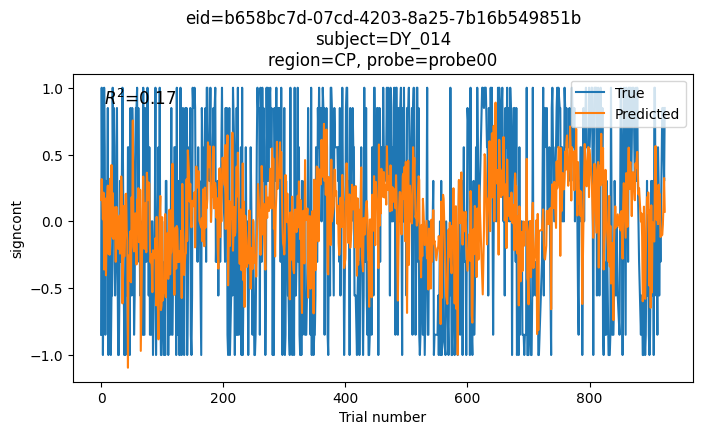

In [17]:
t = np.where(curr_fit["mask"])[0]
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(t, curr_fit["target"], label="True")
ax.plot(t, curr_fit["predictions_test"], label="Predicted")
ax.set_xlabel("Trial number")
ax.set_ylabel(params["target"])
ax.set_title(
    "eid=%s\nsubject=%s\nregion=%s, probe=%s"
    % (results["eid"], results["subject"], results["region"][0], results["probe"])
)
ax.text(
    0.05, 0.9, "$R^2$=%1.2f" % curr_fit["scores_test_full"], transform=ax.transAxes, fontsize=12
)
ax.legend(loc="upper right")

In [21]:
results["fit"][0].keys()

dict_keys(['scores_test_full', 'scores_train', 'scores_test', 'Rsquared_test_full', 'weights', 'intercepts', 'target', 'predictions_test', 'regressors', 'idxes_test', 'idxes_train', 'best_params', 'n_folds', 'mask', 'mask_trials_and_targets', 'mask_diagnostics', 'df', 'pseudo_id', 'run_id', 'cluster_uuids'])

In [2]:
def compute_four_group_weights(y, congruent_mask):
    """
    Computes sample weights balancing the four subgroups:
    Left-Congruent, Left-Incongruent, Right-Congruent, Right-Incongruent.
    """
    # Create the 4 groups
    # y is assumed to be 0 or 1. If -1/1, adjust accordingly.
    # We combine y and mask to get unique group IDs: 0, 1, 2, 3

    # 0: Left (0) & Incongruent (False)
    # 1: Left (0) & Congruent (True)
    # 2: Right (1) & Incongruent (False)
    # 3: Right (1) & Congruent (True)

    group_labels = y * 2 + congruent_mask.astype(int)

    # Count occurrences of each group
    unique_groups, counts = np.unique(group_labels, return_counts=True)
    n_samples = len(y)
    n_groups = len(unique_groups)

    # Calculate weight for each group: N_total / (N_groups * N_group_i)
    # This ensures each group contributes equally to the loss.
    weights = np.zeros(n_samples)
    for group, count in zip(unique_groups, counts):
        weight = n_samples / (n_groups * count)
        weights[group_labels == group] = weight

    return weights

In [5]:
y = np.concatenate([np.ones(100), np.zeros(100)])

In [7]:
congruent = np.concatenate([np.ones(160), np.zeros(40)])

In [8]:
wx = compute_four_group_weights(y, congruent)

In [12]:
wx

array([0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666